# PBQ-01 resource addendum practice

This companion notebook adds official FAQ, pre-lecture, and in-class details that were not fully explicit in the original PBQ-01 practice notebook: Jupyter workflow, AI/debugging guidance, vectorization performance, sets, append vs extend, pandas parse_dates and loc/iloc, None/NaN vs zero, conda vs pip, and a library map for quant work.

## Setup

Load the addendum reference tables and the TCS price file.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display

root = Path(".")
workflow = pd.read_csv(root / "pbq01_workflow_reference.csv")
faq = pd.read_csv(root / "pbq01_faq_reference.csv")
libraries = pd.read_csv(root / "pbq01_library_map.csv")
bench = pd.read_csv(root / "pbq01_vectorization_benchmark.csv")
signal_counts = pd.read_csv(root / "pbq01_tcs_signal_counts.csv")
tcs = pd.read_csv(root / "TCS.NS.csv", parse_dates=["Date"], dayfirst=True).sort_values("Date")
print(f"loaded {len(tcs)} TCS rows and {len(faq)} FAQ reference rules")

loaded 2460 TCS rows and 9 FAQ reference rules


## 1. Notebook workflow and AI guardrails

The official notes expect Anaconda/Jupyter readiness, and the transcript demonstrates using AI to explain errors. The key guardrail is that generated code must still be inspected for strategy logic.

In [2]:
workflow

,topic,source_point,practical_note
0,Jupyter cell types,Code runs Python; Markdown stores notes and ex...,Use markdown to document every idea before code
1,Command vs edit mode,Command mode moves/manages cells; edit mode ch...,Blue border means command mode in classic Jupyter
2,Help tools,"Use help(obj), obj?, tab completion, and error...",Read errors before changing random code
3,AI assistants,Useful for explaining errors and generating ex...,Verify logic before using any generated tradin...
4,Anaconda/Jupyter,Recommended beginner setup for notebooks,VS Code is fine if already comfortable
5,conda vs pip,pip installs Python packages; conda also manag...,Use environments to avoid dependency conflicts


## 2. Vectorization benchmark

PBQ-01 introduces NumPy because array operations are not just shorter; they are much faster for quant calculations.

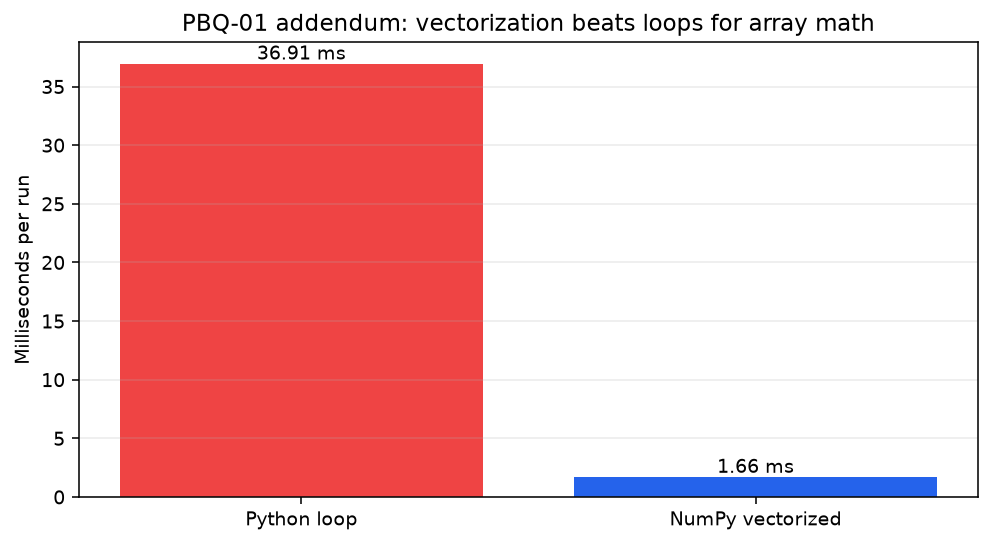

,method,seconds,speedup_vs_vectorized
0,Python loop,0.036910,22.217353
1,NumPy vectorized,0.001661,1.000000


In [3]:
display(Image(filename="chart_addendum_1_pbq01_vectorization_benchmark.png"))
bench

## 3. Data structures beyond the basic three

Lists are mutable, tuples are immutable, dictionaries map keys to values, and sets hold unique unordered values. The FAQ also clarifies append vs extend.

In [4]:
stocks = ["TCS", "INFY"]
stocks.append(["RELIANCE", "HDFCBANK"])
print("append keeps the list as one new element:", stocks)

stocks = ["TCS", "INFY"]
stocks.extend(["RELIANCE", "HDFCBANK"])
print("extend adds each item separately:", stocks)

tickers_with_duplicates = ["TCS", "INFY", "TCS", "RELIANCE"]
print("set removes duplicates:", set(tickers_with_duplicates))

append keeps the list as one new element: ['TCS', 'INFY', ['RELIANCE', 'HDFCBANK']]
extend adds each item separately: ['TCS', 'INFY', 'RELIANCE', 'HDFCBANK']
set removes duplicates: {'TCS', 'INFY', 'RELIANCE'}


## 4. pandas parse_dates, loc, iloc, and assignment

The FAQ's practical pandas points are: parse dates on load, use `.loc` for label-based access, use `.iloc` for integer-position access, and assign with explicit row/column selectors.

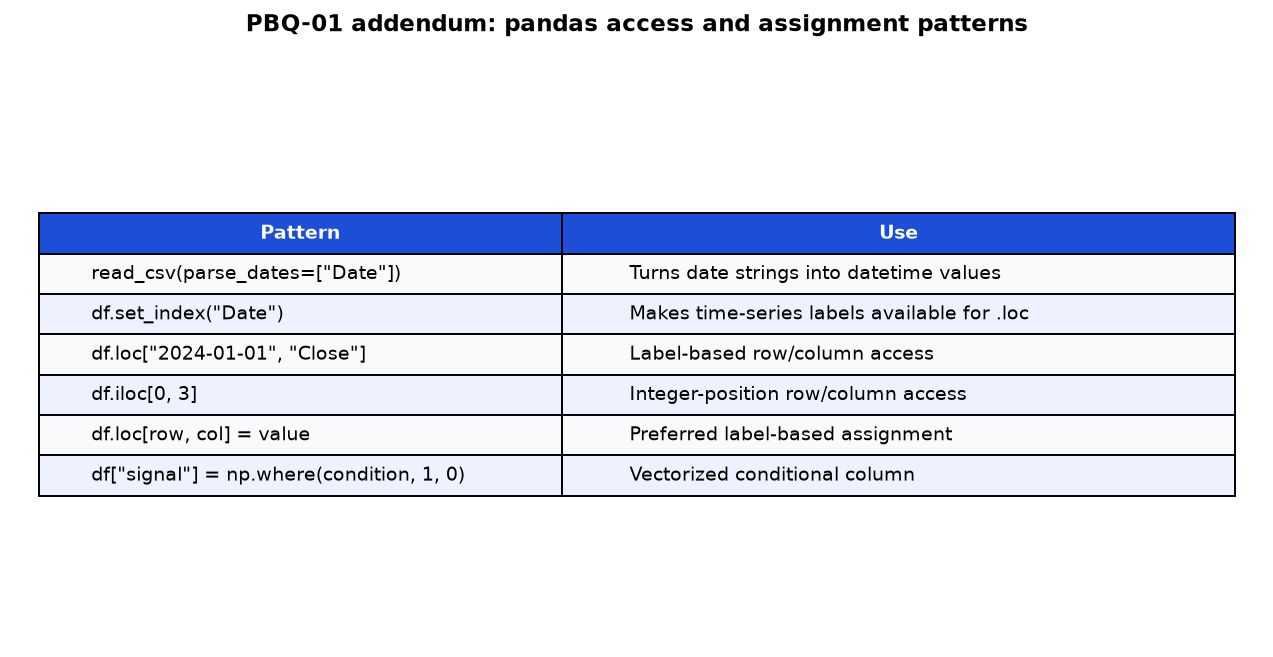

first date label: 2010-04-26
loc by label, Close: 392.5499878
iloc by integer position, Close: 392.5499878


In [5]:
display(Image(filename="chart_addendum_2_pbq01_pandas_access_patterns.png"))

px = tcs.set_index("Date")
first_date = px.index[0]
print("first date label:", first_date.date())
print("loc by label, Close:", px.loc[first_date, "Close"])
print("iloc by integer position, Close:", px.iloc[0]["Close"])

## 5. None/NaN is not zero

Zero is a valid number. `None`, `NaN`, or `np.nan` means missing or undefined data. Rolling indicators create NaN warm-up rows until enough observations exist.

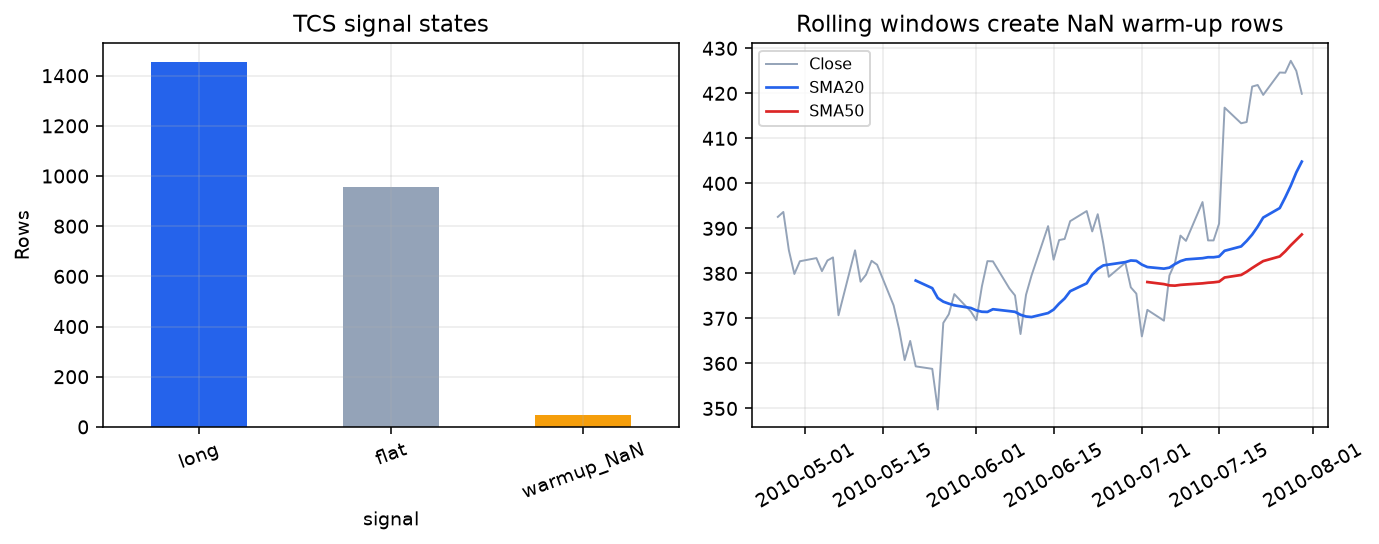

,signal,count
0,long,1456
1,flat,955
2,warmup_NaN,49


In [6]:
display(Image(filename="chart_addendum_3_pbq01_missing_data_signals.png"))
signal_counts

## 6. Library map for later PBQ/DMP/MLT work

The FAQ lists packages you will see repeatedly in the rest of the program.

In [7]:
libraries

,library,use
0,numpy,Numerical arrays and vectorized math
1,pandas,Series/DataFrame time-series data manipulation
2,matplotlib,Foundational static plotting
3,seaborn,Higher-level statistical plotting
4,plotly,Interactive charts
5,yfinance,Historical market data from Yahoo Finance
6,pandas-datareader,Economic and financial data access
7,scikit-learn,Machine-learning models and preprocessing
8,statsmodels,Statistical models and time-series tools
9,quantstats,Portfolio and strategy performance analytics


## Addendum summary

The original notebook teaches the first Python syntax and TCS signal workflow. This addendum adds the source-backed operational details: notebook workflow, debugging, vectorization, pandas access patterns, missing data, environments, and the quant Python library map.